# Autoregressive moving average process (ARMA)

The autoregressive moving average process is a combination of the autoregressive process and the moving average process.

It is denoted as ARMA(p,q), where p is the order of the autoregressive process, and q is the order of the moving average process. The general equation of the ARMA(p,q) model is

`yt = C + ϕ1yt–1 + ϕ2yt–2 +⋅⋅⋅+ ϕpyt–p + μ + ϵt + θ1ϵt–1 + θ2ϵt–2 +⋅⋅⋅+ θqϵt–q`

The order `p` determines the number of past values that affect the present value. Similarly, the order `q` determines the number of past error terms that affect the present value

An ARMA(0,q) process is equivalent to an MA(q) process, since the order p = 0 cancels the AR(p) portion. An ARMA(p,0) process is equivalent to an AR(p) process, since the order q = 0 cancels the MA(q) portion.

https://github.com/marcopeix/TimeSeriesForecastingInPython/blob/master/CH06/CH06.ipynb

It states that the present value is linearly dependent on its own previous values and a constant, just like in an autoregressive process, as well as on the mean of the series, the current error term, and past error terms, like in a moving average process.

In [4]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Identifying a stationary ARMA process

In [6]:
np.random.seed(42)

ar1 = np.array([1, -0.33])
ma1 = np.array([1, 0.9])

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

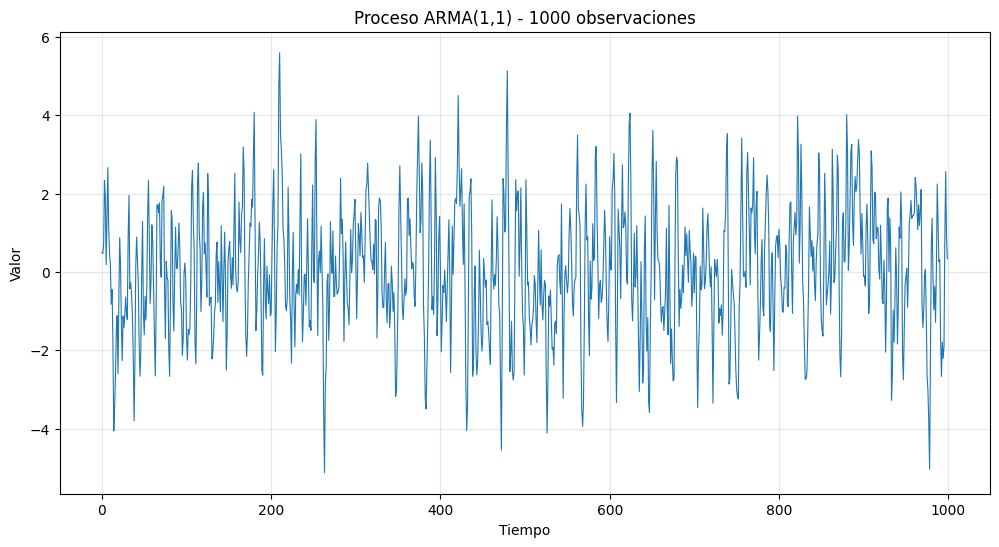

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(ARMA_1_1, linewidth=0.8)
plt.title('Proceso ARMA(1,1) - 1000 observaciones')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
ADF_result = adfuller(ARMA_1_1)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -6.4298786820426965
p-value: 1.707846668009642e-08


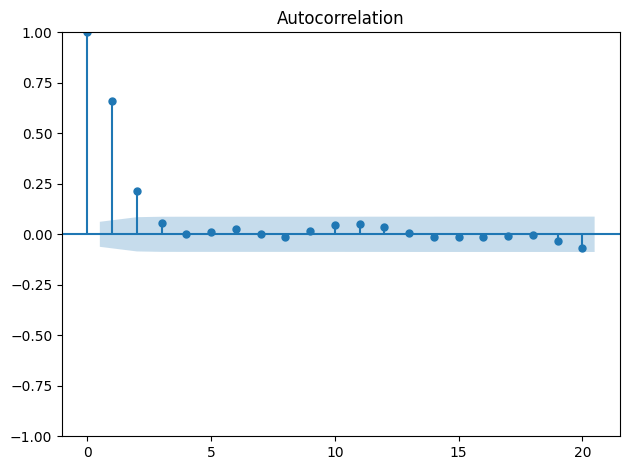

In [11]:
plot_acf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('images/CH06_F05.png', dpi=300)

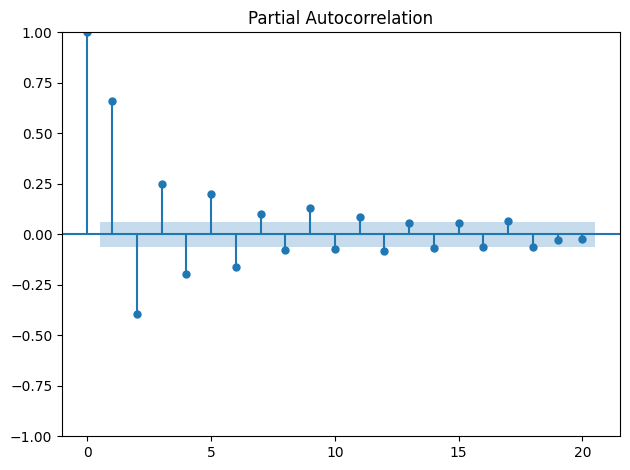

In [10]:
plot_pacf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('images/CH06_F06.png', dpi=300)

## 2. Select best model